In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import f1_score, precision_score, recall_score


In [2]:
"""task 1:
Apply all EDA Python Techniques you learn to answer the following questions:
- How many rows and columns does the dataset have?
- Which features are numerical? Which are categorical?
- Are there any missing values? How many, and in which columns?
- What does the distribution of car prices look like?
- Which features seem most related to price?"""

df = pd.read_csv("car_price.csv")

In [3]:
# df size/shape
rows = df.shape[0]
cols = df.shape[1]
print(f"Rows: {rows}\nColumns: {cols}\n")

Rows: 72435
Columns: 10



In [4]:
# feature types
print(df.info())
floats = ["year","price","mileage","tax","mpg","engineSize"]
strings = ["model","transmission","fuelType","Make"]
print(f"Numerical features are: {floats}")
print(f"Categorical Features are: {strings}\n")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72435 entries, 0 to 72434
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         68814 non-null  object 
 1   year          68813 non-null  float64
 2   price         68814 non-null  float64
 3   transmission  68812 non-null  object 
 4   mileage       68813 non-null  float64
 5   fuelType      68813 non-null  object 
 6   tax           68814 non-null  float64
 7   mpg           68814 non-null  float64
 8   engineSize    68813 non-null  float64
 9   Make          68814 non-null  object 
dtypes: float64(6), object(4)
memory usage: 5.5+ MB
None
Numerical features are: ['year', 'price', 'mileage', 'tax', 'mpg', 'engineSize']
Categorical Features are: ['model', 'transmission', 'fuelType', 'Make']



In [5]:
print(df.describe())
print("\n")

               year          price        mileage           tax           mpg  \
count  68813.000000   68814.000000   68813.000000  68814.000000  68814.000000   
mean    2017.077660   16583.919261   23179.439539    116.930421     55.836352   
std        2.099474    9304.412707   21347.569657     64.081931     17.043643   
min     1996.000000     495.000000       1.000000      0.000000      0.300000   
25%     2016.000000   10167.250000    7199.000000     30.000000     47.900000   
50%     2017.000000   14495.000000   17521.000000    145.000000     55.400000   
75%     2019.000000   20359.750000   32478.000000    145.000000     62.800000   
max     2020.000000  145000.000000  323000.000000    580.000000    470.800000   

         engineSize  
count  68813.000000  
mean       1.635373  
std        0.561734  
min        0.000000  
25%        1.200000  
50%        1.600000  
75%        2.000000  
max        6.600000  




In [6]:
# check for nulls
print("Null values: (column, number of nulls)\n")
print(df.isnull().sum())

Null values: (column, number of nulls)

model           3621
year            3622
price           3621
transmission    3623
mileage         3622
fuelType        3622
tax             3621
mpg             3621
engineSize      3622
Make            3621
dtype: int64


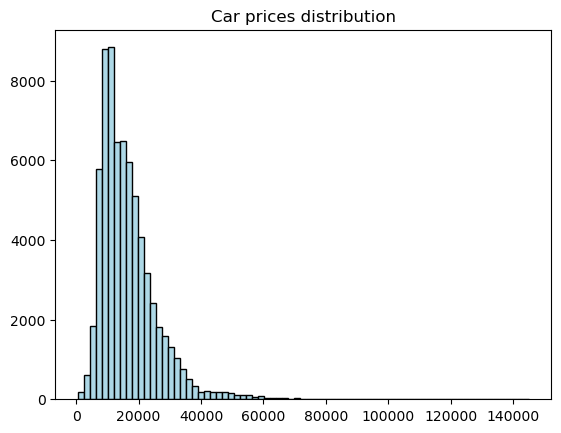

In [7]:
# distribution of car prices
car_prices = df["price"]
bins_num = 75 # doing sqrt(rows) will equal 274 which is too many to interpret
plt.hist(car_prices, bins=bins_num, color="lightblue", edgecolor="black")
plt.title("Car prices distribution")
plt.show()

Distribution is similar to a normal distribution with a positive (right) skew in both graphs, meaning most cars in the dataset are on the cheaper side, with expensive cars being rare

['audi' nan 'BMW' 'Ford' 'vw' 'toyota' 'skoda' 'Hyundai']


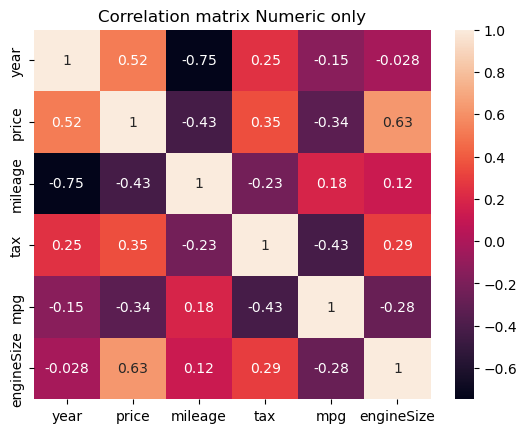

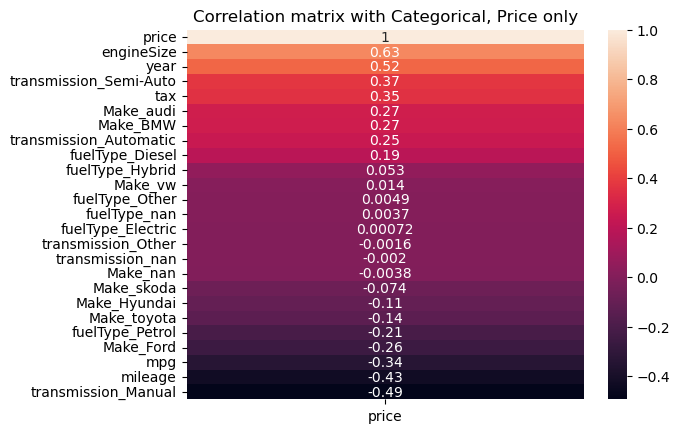

In [8]:
# correlation matrix
print(df['Make'].unique())
# model has too many values to include in this matrix, make has 8 unique values which is fine
encoder = OneHotEncoder(sparse_output=False)

categories = ['transmission','fuelType','Make']
encoded_categories = encoder.fit_transform(df[categories])

encoded_df = pd.DataFrame(encoded_categories, columns=encoder.get_feature_names_out(categories))

new_df = pd.concat([df.drop(columns=['transmission','fuelType','Make']), encoded_df], axis=1)
corr_matrix_numeric_only = df.corr(method='pearson', numeric_only=True)
corr_matrix = new_df.corr(method='pearson', numeric_only=True)
sns.heatmap(corr_matrix_numeric_only, annot=True)
plt.title("Correlation matrix Numeric only")
plt.show()

# show price correlations only
sns.heatmap(corr_matrix[['price']].sort_values(by='price', ascending=False), annot=True)
plt.title("Correlation matrix with Categorical, Price only")
plt.show()

Price is most correlated to Engine size, followed by year, then transmission manual, and least correlated to fuel type electric (if we include categorical data), or to mpg (if we only include numerical data)

In [9]:
df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,Make
0,A1,2017.0,12500.0,Manual,15735.0,Petrol,150.0,55.4,1.4,audi
1,A6,2016.0,16500.0,Automatic,36203.0,Diesel,20.0,64.2,2.0,audi
2,A1,2016.0,11000.0,Manual,29946.0,Petrol,30.0,55.4,1.4,audi
3,A4,2017.0,16800.0,Automatic,25952.0,Diesel,145.0,67.3,2.0,audi
4,A3,2019.0,17300.0,Manual,1998.0,Petrol,145.0,49.6,1.0,audi


In [10]:
#remove rows with missing values in the price column to ensure data quality
df = df.dropna(subset=['price'])
df.shape

(68814, 10)

feature engineering (price_category)  -> knn

The price distribution is right-skewed, with most cars concentrated in the lower and mid price ranges, and a long tail of high-priced cars.

use quantiles instead of mean/median because the price distribution is right-skewed

Using quantiles ensures that the data is split into approximately equal-sized groups based on the actual distribution

Decide on the thresholds (price boundaries) for each category.

the thresholds were defined using 33% and 66% quantiles 

In [11]:
train, test = train_test_split(df, test_size=0.2, random_state=1)
print(f"Train size: {train.shape[0]} rows, {train.shape[1]} columns")
print(f"Test size: {test.shape[0]} rows, {test.shape[1 ]} columns")

Train size: 55051 rows, 10 columns
Test size: 13763 rows, 10 columns


In [12]:
low = train['price'].quantile(0.33) #quantile based on the distribution of prices(right-skewed) not the values themselves
high = train['price'].quantile(0.66)

In [13]:
train['price_category'] = np.select( #create 'price_category' column
    [train['price'] < low, train['price'] < high], #conditions
    ['Cheap', 'Moderate'], #choices
    default='Expensive' #default
)

test['price_category'] = np.select(
    [test['price'] < low, test['price'] < high],
    ['Cheap', 'Moderate'],
    default='Expensive'
)

This code imputes missing values in numerical columns using the median to reduce the impact of outliers

In [14]:
num_imputer = SimpleImputer(strategy='median')
num_cols = ['mileage', 'tax', 'mpg', 'engineSize', 'year']
train[num_cols] = num_imputer.fit_transform(train[num_cols])
test[num_cols] = num_imputer.transform(test[num_cols])


fill missing values in categorical columns using the most frequent value

In [15]:
catg_imputer = SimpleImputer(strategy='most_frequent')
catg_cols = ['model', 'transmission', 'fuelType','Make']
train[catg_cols] = catg_imputer.fit_transform(train[catg_cols])
test[catg_cols] = catg_imputer.transform(test[catg_cols])

In [16]:
for col in num_cols:
    Q1 = train[col].quantile(0.25)
    Q3 = train[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers_train = len(train[(train[col] < lower) | (train[col] > upper)])
    outliers_test = len(test[(test[col] < lower) | (test[col] > upper)])
    
    print("column:", col)
    print("train outliers:", outliers_train)
    print("test outliers:", outliers_test)
    print("-------------------")

column: mileage
train outliers: 2445
test outliers: 588
-------------------
column: tax
train outliers: 15895
test outliers: 3906
-------------------
column: mpg
train outliers: 788
test outliers: 212
-------------------
column: engineSize
train outliers: 241
test outliers: 69
-------------------
column: year
train outliers: 922
test outliers: 224
-------------------


limit extreme values in numerical columns using IQR boundaries from the training data to reduce their impact while avoiding data leakage.

In [17]:
for col in num_cols:
    Q1 = train[col].quantile(0.25)
    Q3 = train[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    train[col] = train[col].clip(lower, upper)
    test[col] = test[col].clip(lower, upper)

    outliers_train = len(train[(train[col] < lower) | (train[col] > upper)])
    outliers_test = len(test[(test[col] < lower) | (test[col] > upper)])

    print("column:", col)
    print("train outliers:", outliers_train)
    print("test outliers:", outliers_test)
    print("-------------------")


column: mileage
train outliers: 0
test outliers: 0
-------------------
column: tax
train outliers: 0
test outliers: 0
-------------------
column: mpg
train outliers: 0
test outliers: 0
-------------------
column: engineSize
train outliers: 0
test outliers: 0
-------------------
column: year
train outliers: 0
test outliers: 0
-------------------


In [18]:
train['model'].unique()


array([' I10', ' Aygo', ' A5', ' X1', ' 2 Series', ' Focus', ' Yaris',
       ' Auris', ' 5 Series', ' Corolla', ' EcoSport', ' Fiesta', ' Edge',
       ' Q7', ' Golf', ' Passat', ' Z4', ' Tucson', ' 1 Series', ' A3',
       ' 3 Series', ' Octavia', ' X5', ' Q3', ' Q5', ' Ka+', ' Q2',
       ' I20', ' Tiguan', ' Kuga', ' Citigo', ' Hilux', ' Karoq',
       ' Tiguan Allspace', ' A1', ' Mondeo', ' T-Cross', ' Kona', ' Q8',
       ' M4', ' Ioniq', ' X2', ' RAV4', ' IX20', ' A6', ' Superb',
       ' Jetta', ' 4 Series', ' B-MAX', ' Polo', ' M6', ' A4',
       ' Caddy Maxi Life', ' Fabia', ' Galaxy', ' C-HR', ' Grand C-MAX',
       ' Touareg', ' X3', ' Up', ' Scala', ' X6', ' T-Roc', ' C-MAX',
       ' i3', ' Verso', ' Kodiaq', ' I30', ' Land Cruiser', ' Kamiq',
       ' Santa Fe', ' 6 Series', ' Avensis', ' Arteon', ' Golf SV', ' R8',
       ' Prius', ' GT86', ' Amarok', ' KA', ' Touran', ' S-MAX',
       ' Scirocco', ' Tourneo Connect', ' A7', ' Rapid', ' Fusion',
       ' Yeti Outdoor', 

In [19]:
test['model'].unique()

array([' Q7', ' I10', ' Tucson', ' Touran', ' Fiesta', ' A3', ' 2 Series',
       ' Octavia', ' I30', ' Golf', ' X4', ' Caddy Maxi Life', ' Q2',
       ' A7', ' X5', ' Polo', ' EcoSport', ' Arteon', ' Yeti Outdoor',
       ' Q5', ' A4', ' Santa Fe', ' Tiguan', ' A1', ' Corolla', ' A5',
       ' 4 Series', ' Karoq', ' Aygo', ' Scala', ' Edge', ' IX20',
       ' Kuga', ' Focus', ' Golf SV', ' S-MAX', ' I40', ' A6', ' Auris',
       ' T-Roc', ' Fabia', ' 5 Series', ' Superb', ' C-MAX', ' Yaris',
       ' 1 Series', ' X1', ' Up', ' 3 Series', ' Mondeo', ' Caravelle',
       ' Sharan', ' Grand C-MAX', ' Q3', ' Passat', ' Scirocco',
       ' Tourneo Connect', ' RS4', ' Rapid', ' Kona', ' Ka+', ' I800',
       ' I20', ' Galaxy', ' TT', ' Puma', ' Avensis', ' RAV4', ' Yeti',
       ' Kodiaq', ' T-Cross', ' Kamiq', ' Citigo', ' Prius',
       ' Tiguan Allspace', ' KA', ' Touareg', ' Ioniq', ' Z4', ' A8',
       ' i3', ' 6 Series', ' B-MAX', ' C-HR', ' X2', ' California', ' X3',
       ' 8 Serie

In [20]:
different = set(test['model'].unique()) - set(train['model'].unique())
print(different)

{' Escort', ' Ranger'}


One Hot Encoding to categorical features since there is no inherent order between the categories,ensuring a numerical representation for machine learning models

Target Encoding was applied to the 'model' column because it contains hundreds of unique values.
Using One-Hot Encoding on it would create too many columns (high dimensionality).
each model name is replaced with the mean price of that model calculated from the training data only

In [21]:
# target ecoding  
model_mean = train.groupby('model')['price'].mean()
train['model_enc'] = train['model'].map(model_mean)
test['model_enc'] = test['model'].map(model_mean)

price_mean = train['price'].mean()
test['model_enc'] = test['model_enc'].fillna(price_mean)

#one hot encoding   
cat_cols = ['Make', 'transmission', 'fuelType']
enc = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
train_enc = enc.fit_transform(train[cat_cols])
test_enc = enc.transform(test[cat_cols])

new_cols = enc.get_feature_names_out(cat_cols)
train_cat_df = pd.DataFrame(train_enc, columns=new_cols, index=train.index)
test_cat_df = pd.DataFrame(test_enc, columns=new_cols, index=test.index)

x_train = pd.concat([train.drop(columns=cat_cols + ['price', 'price_category', 'model']), train_cat_df], axis=1)
x_test = pd.concat([test.drop(columns=cat_cols + ['price', 'price_category', 'model']),test_cat_df], axis=1)
y_train = train['price']
y_test = test['price']

In [22]:
# take a copy before scaling
x_train_no_scale = x_train.copy()
x_test_no_scale = x_test.copy()

Numerical features were scaled using StandardScaler to standardize feature distributions. This is important for KNN, as it relies on distance based calculations.
(x − μ) / σ 

In [23]:
scaling_cols = ['mileage', 'tax', 'mpg', 'engineSize', 'year', 'model_enc']
scaler = StandardScaler()
x_train[scaling_cols] = scaler.fit_transform(x_train[scaling_cols])
x_test[scaling_cols] = scaler.transform(x_test[scaling_cols])

In [24]:
print("x_train shape:", x_train.shape)
print("x_test shape:", x_test.shape)

x_train shape: (55051, 22)
x_test shape: (13763, 22)


In [25]:
x_train.head()

,year,mileage,tax,mpg,engineSize,model_enc,Make_BMW,Make_Ford,Make_Hyundai,Make_audi,...,Make_vw,transmission_Automatic,transmission_Manual,transmission_Other,transmission_Semi-Auto,fuelType_Diesel,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol
70471,-0.064949,-0.192915,0.462955,0.219755,-0.814585,-1.230032,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
58577,-0.064949,0.263652,-1.650831,1.226742,-1.196277,-1.213174,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
8373,-1.150903,0.843449,0.462955,0.014792,0.712185,1.010043,0.0,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
11672,-0.064949,1.068963,0.462955,0.014792,0.712185,0.453088,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
20801,-0.064949,0.366491,-0.382560,-0.261461,-0.242046,0.426336,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


regression:

In [26]:
model = LinearRegression()
model.fit(x_train, y_train)
y_pred = model.predict(x_test)
print("Mean Squared Error:", f"{mean_squared_error(y_test, y_pred):.4f}")
print("R2 Score:", f"{r2_score(y_test, y_pred):.4f}")

Mean Squared Error: 12936848.3451
R2 Score: 0.8489


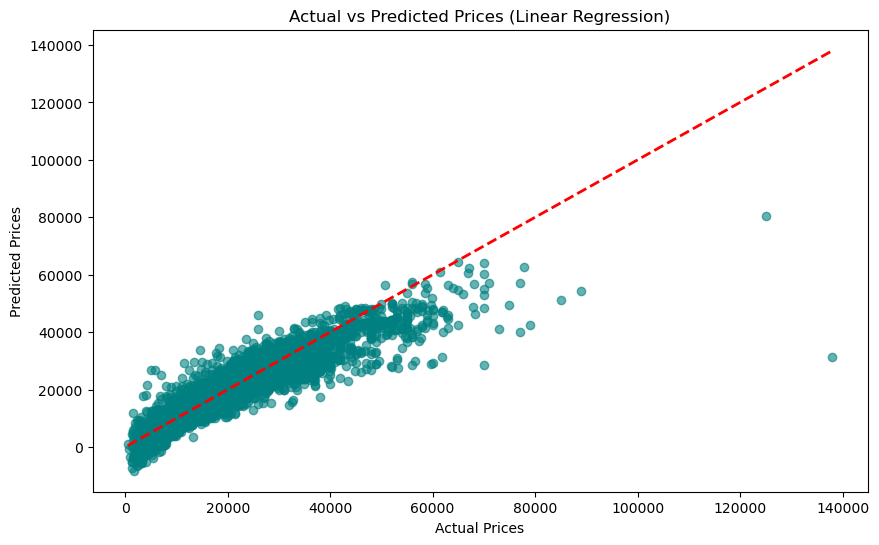

In [27]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Actual vs Predicted Prices (Linear Regression)')
plt.show()

KNN

In [28]:
train['price_category'].value_counts() 

price_category
Expensive    18744
Moderate     18171
Cheap        18136
Name: count, dtype: int64

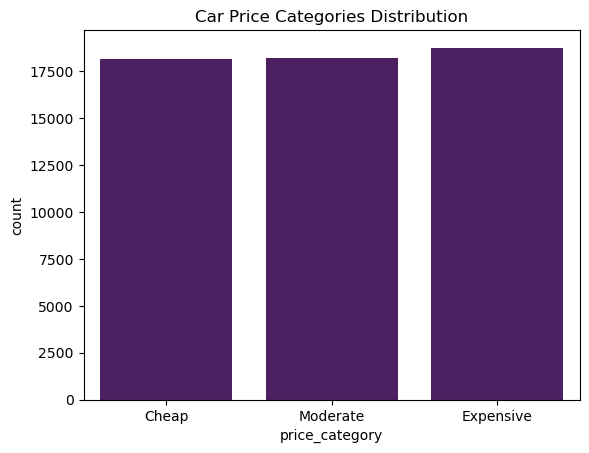

In [29]:
sns.countplot(x='price_category', data=train, order=['Cheap', 'Moderate', 'Expensive'], color="#51156D")
plt.title("Car Price Categories Distribution")
plt.show()

In [30]:
parameter_grid = {
    'n_neighbors': range(3, 20, 2),  # Test values from 3 to 19 (odd numbers only)
    'metric': ['euclidean', 'manhattan'],  # Different distance metrics
}

In [31]:
knn = KNeighborsClassifier()
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

## Setup GridSearchCV
grid_search = GridSearchCV(
    estimator=knn,
    param_grid=parameter_grid,
    cv=kfold,
    scoring='accuracy',
    n_jobs=-1,
)

In [32]:
y_train_knn = train['price_category']
y_test_knn = test['price_category']

In [33]:
x_train_knn = x_train
x_test_knn = x_test

In [34]:
grid_search.fit(x_train_knn, y_train_knn)

print("Best Parameters:", grid_search.best_params_)
print("Best CV Accuracy: {:.4f}".format(grid_search.best_score_))

Best Parameters: {'metric': 'manhattan', 'n_neighbors': 7}
Best CV Accuracy: 0.8764


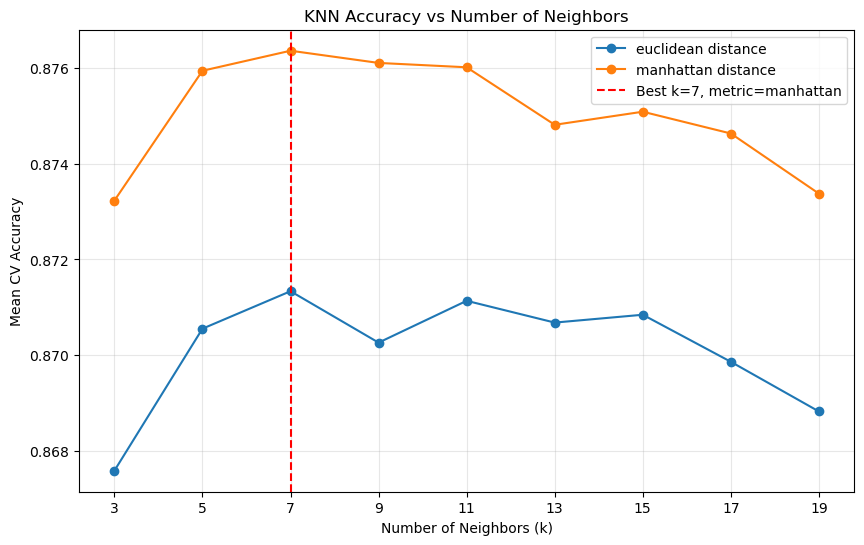

In [35]:
results = pd.DataFrame(grid_search.cv_results_)

plt.figure(figsize=(10,6))

# Plot for each metric type
for metric in ['euclidean', 'manhattan']:
    subset = results[results['param_metric'] == metric]
    plt.plot(subset['param_n_neighbors'],
             subset['mean_test_score'],
             label=f'{metric} distance',
             marker='o')

best_k = grid_search.best_params_['n_neighbors']
best_metric = grid_search.best_params_['metric']
plt.axvline(best_k, color='red', linestyle='--',
            label=f'Best k={best_k}, metric={best_metric}')

plt.title('KNN Accuracy vs Number of Neighbors')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Mean CV Accuracy')
plt.xticks(np.arange(3, 20, 2))
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [36]:
y_pred = grid_search.predict(x_test_knn)

In [37]:
print("Accuracy Score: ", accuracy_score(y_test_knn, y_pred))
print("Precision:", precision_score(y_test_knn, y_pred, average='macro'))
print("Recall:", recall_score(y_test_knn, y_pred, average='macro'))
print("F1-score:", f1_score(y_test_knn, y_pred, average='macro')) 
#weighted -> if dataset is imbalanced && classification (take weightes from each class)
#macro -> if dataset is balanced (each class is equally important) -> fair between classes
#our dataset is balanced beacause no high difference in the number of samples in each class
'''
price_category
Expensive    18744
Moderate     18171
Cheap        18136
'''

Accuracy Score:  0.8788781515657923
Precision: 0.8792475263495928
Recall: 0.8788097420174744
F1-score: 0.8790113841238129


'\nprice_category\nExpensive    18744\nModerate     18171\nCheap        18136\n'

Confusion Matrix

In [38]:
print(classification_report(y_test_knn, y_pred))
#macro avg == weighted avg -> our dataset is balanced so macro avg is the right choice

              precision    recall  f1-score   support

       Cheap       0.91      0.90      0.90      4461
   Expensive       0.91      0.91      0.91      4706
    Moderate       0.82      0.83      0.82      4596

    accuracy                           0.88     13763
   macro avg       0.88      0.88      0.88     13763
weighted avg       0.88      0.88      0.88     13763



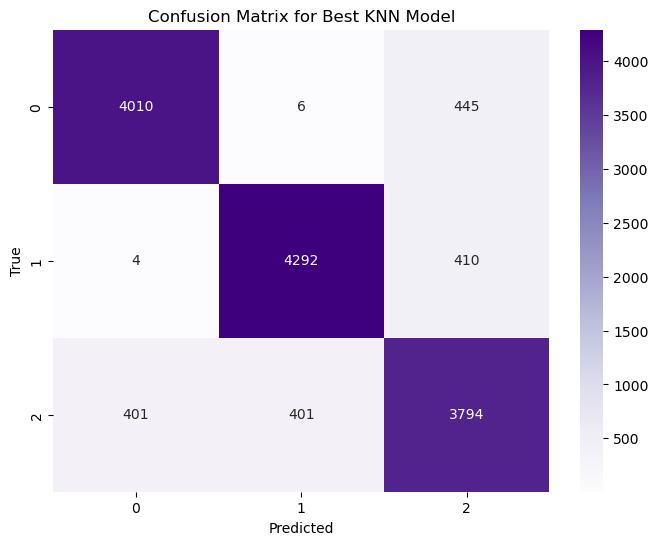

In [39]:
cm = confusion_matrix(y_test_knn, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples')
plt.title('Confusion Matrix for Best KNN Model')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

 Analysis and Discussion

6.1  Model Comparison

Which model performed better, and what does better mean in each context?

The Linear Regression model and the KNN classifier cannot be directly compared using a single metric because they solve different problems.

Linear Regression performed better for the regression task, as it is designed to predict continuous values (exact car prices) and achieved an R² score of 0.84, which indicates strong predictive performance.

KNN performed better for the classification task, achieving an accuracy of 0.87 in classifying cars into price categories (Cheap, Moderate, Expensive).

Therefore, the concept of "better" depends on the task:
- Linear Regression is better for predicting exact prices.
- KNN is better for classifying cars into categories.

Neither model is universally better; each is optimal for its specific objective.


Is classification easier than regression on this dataset? Why or why not? 
Classification is easier than regression in this dataset because:

- It simplifies the problem (3 categories instead of exact values)
- Small prediction errors do not matter as much

However, regression is harder because:

- It requires predicting exact numerical values
- Even small errors are penalized

Does converting price into categories lose important information? 
Yes, converting prices into categories loses information.

For example:

- A car worth 100,000 and 200,000 might both be classified as "Expensive" Or car in range(10,000 , 11,000) might both be cheap
- But in reality, they are very different in price

So classification simplifies the data but reduces precision.

6.2  Sensitivity Analysis 

What happens if you remove the most correlated feature? Does performance drop a lot? 
Removing the most correlated feature (engineSize from heapmap) caused a noticeable drop in model performance.

This shows that this feature is very important for predicting car prices.

In [40]:
x_train_drop = x_train.drop(columns=['engineSize'])
x_test_drop = x_test.drop(columns=['engineSize'])

model2 = LinearRegression()
model2.fit(x_train_drop, y_train)

y_pred2 = model2.predict(x_test_drop)

print("New R2:", r2_score(y_test, y_pred2))

New R2: 0.8285450703484325


Try running KNN without scaling — how much does performance change? 
KNN performance dropped significantly without scaling.

This because knn depends on distance, so features with larger scales dominate the calculation 

In [41]:
#knn with scaling
x_train_knn = x_train  
x_test_knn = x_test

y_train_knn = train['price_category']
y_test_knn = test['price_category']

knn = KNeighborsClassifier(n_neighbors=5, metric='euclidean')
knn.fit(x_train_knn, y_train_knn)

y_pred = knn.predict(x_test_knn)

# evaluation
print("Accuracy:", accuracy_score(y_test_knn, y_pred))
print(classification_report(y_test_knn, y_pred))

Accuracy: 0.8738647097289836
              precision    recall  f1-score   support

       Cheap       0.90      0.90      0.90      4461
   Expensive       0.91      0.90      0.91      4706
    Moderate       0.81      0.82      0.81      4596

    accuracy                           0.87     13763
   macro avg       0.87      0.87      0.87     13763
weighted avg       0.87      0.87      0.87     13763



In [42]:
#KNN without scaling
knn_no_scale = KNeighborsClassifier(n_neighbors=5, metric='euclidean')
knn_no_scale.fit(x_train_no_scale, y_train_knn)

y_pred_no_scale = knn_no_scale.predict(x_test_no_scale)

print("Accuracy Without scaling:", accuracy_score(y_test_knn, y_pred_no_scale))
print(classification_report(y_test_knn, y_pred_no_scale))

Accuracy Without scaling: 0.7450410520962
              precision    recall  f1-score   support

       Cheap       0.77      0.82      0.79      4461
   Expensive       0.81      0.81      0.81      4706
    Moderate       0.64      0.61      0.63      4596

    accuracy                           0.75     13763
   macro avg       0.74      0.75      0.74     13763
weighted avg       0.74      0.75      0.74     13763



Try a different threshold for your price categories — does KNN accuracy change 
significantly?

Changing the price thresholds directly affects how the dataset is labeled into classes. 
When thresholds change, the distribution of Cheap, Moderate, and Expensive cars changes, which can lead to class imbalance.

Since KNN is sensitive to class distribution and local neighborhood structure, its performance may change significantly.

In our experiments, changing thresholds resulted in changes in accuracy and F1-score, showing that the model is sensitive to how the target classes are defined.

In [43]:
# Calculate thresholds using quantiles
train_exp = train.copy()
test_exp = test.copy()

low = train_exp['price'].quantile(0.25)
high = train_exp['price'].quantile(0.75)

train_exp['price_category'] = np.select(
    [train_exp['price'] < low, train_exp['price'] < high],
    ['Cheap', 'Moderate'],
    default='Expensive'
)

test_exp['price_category'] = np.select(
    [test_exp['price'] < low, test_exp['price'] < high],
    ['Cheap', 'Moderate'],
    default='Expensive'
)


In [44]:
print("Old Threshold:")
print(train['price_category'].value_counts())

print("\nNew Threshold:")
print(train_exp['price_category'].value_counts())

Old Threshold:
price_category
Expensive    18744
Moderate     18171
Cheap        18136
Name: count, dtype: int64



New Threshold:
price_category
Moderate     27533
Expensive    13763
Cheap        13755
Name: count, dtype: int64


In [48]:
y_train_new = train_exp['price_category']
y_test_new = test_exp['price_category']

knn_new = KNeighborsClassifier(n_neighbors=5, metric='euclidean')
knn_new.fit(x_train, y_train_new)

y_pred_new = knn_new.predict(x_test)

print("New threshold accuracy:", accuracy_score(y_test_new, y_pred_new))
print(classification_report(y_test_new, y_pred_new))

New threshold accuracy: 0.8838189348252561
              precision    recall  f1-score   support

       Cheap       0.88      0.86      0.87      3348
   Expensive       0.91      0.87      0.89      3478
    Moderate       0.88      0.90      0.89      6937

    accuracy                           0.88     13763
   macro avg       0.89      0.88      0.88     13763
weighted avg       0.88      0.88      0.88     13763



Plot 1: Price vs Mileage (Relationship Plot)

This plot shows the relationship between mileage and car price.

We observe a negative correlation: as mileage increases, the price tends to decrease.

This makes sense because cars with higher mileage are generally older and more worn out, leading to lower market value

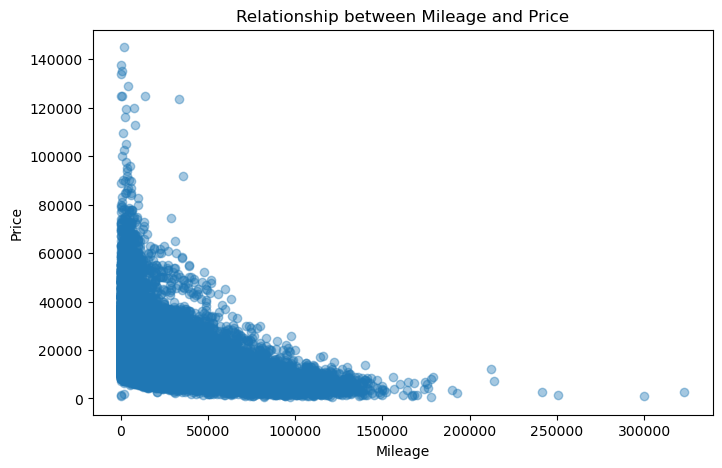

In [45]:
plt.figure(figsize=(8,5))
plt.scatter(df['mileage'], df['price'], alpha=0.4)
plt.xlabel("Mileage")
plt.ylabel("Price")
plt.title("Relationship between Mileage and Price")
plt.show()

Plot 2: Barplot for price and fuelType

This bar plot shows the average price for each fuel type. 
It helps compare how fuel type affects car price.

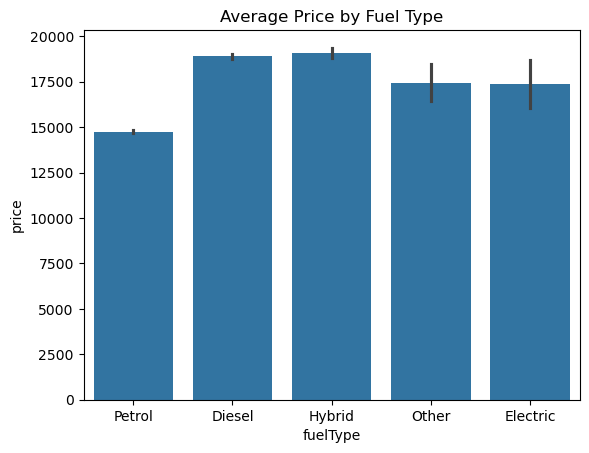

In [46]:
sns.barplot(x='fuelType', y='price', data=df)
plt.title("Average Price by Fuel Type")
plt.show()